In [14]:
#Linear model
from sklearn.linear_model import (LogisticRegression, SGDClassifier, Perceptron, PassiveAggressiveClassifier)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#tree model
from sklearn.tree import DecisionTreeClassifier

#Ensemble model
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingClassifier, VotingClassifier)

#Neural network
from sklearn.neural_network import MLPClassifier

#Naive bayes
from sklearn.naive_bayes import (GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB)

#KNN
from sklearn.neighbors import KNeighborsClassifier

#SVM
from sklearn.svm import SVC, LinearSVC

#Base line
from sklearn.dummy import DummyClassifier

#High-performance gradient boosting frameworks
#XGBoost (External Library)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics for Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
df=pd.read_csv('/content/ticket_categorizer.csv')
df.shape

(998, 3)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    998 non-null    object
 1   ticket_text  998 non-null    object
 2   department   998 non-null    object
dtypes: object(3)
memory usage: 23.5+ KB


In [59]:
df.dtypes

,0
ticket_id,object
ticket_text,object
department,object


In [60]:
df.isna().sum()

,0
ticket_id,0
ticket_text,0
department,0


In [61]:
df.columns

Index(['ticket_id', 'ticket_text', 'department'], dtype='object')

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df['department'].value_counts()

,count
department,
hr,250
general,250
technical,249
billing,249


In [9]:
X = df["ticket_text"]
y = df["department"]

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClasses:")
print(y.value_counts())

X shape: (998,)
y shape: (998,)

Classes:
department
hr           250
general      250
technical    249
billing      249
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Class mapping:")

for i, class_name in enumerate(le.classes_):
    print(i, "->", class_name)

Class mapping:
0 -> billing
1 -> general
2 -> hr
3 -> technical


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    stratify=y_encoded,
    random_state=42
)
print("Training:", X_train.shape, y_train.shape)
print("Testing :", X_test.shape, y_test.shape)


Training: (798,) (798,)
Testing : (200,) (200,)


In [15]:
def clean_text(text):
  text=str(text).lower()
  text=re.sub(r'http\S+|www\S+',' ',text)
  text=re.sub(r"[^a-z\s]",' ',text)
  text=re.sub(r"\s+",' ',text)
  text=text.strip()
  return text



In [16]:
X_train_clean=X_train.apply(clean_text)
X_test_clean=X_test.apply(clean_text)

In [22]:
pipeline=Pipeline(
    [('tfidf',TfidfVectorizer()),
     ('classifier',LinearSVC())]
)
pipeline

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('classifier', LinearSVC())])

In [23]:
pipeline.fit(X_train_clean, y_train)
y_pred=pipeline.predict(X_test_clean)
cls_report=classification_report(y_test, y_pred)
print(cls_report)
print("="*60)
con_matrix=confusion_matrix(y_test, y_pred)
print(con_matrix)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50
           3       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[50  0  0  0]
 [ 0 50  0  0]
 [ 0  0 50  0]
 [ 0  0  0 50]]


In [25]:
param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2
    ],

    "tfidf__max_df": [
        0.95,
        1.0
    ],

    "tfidf__sublinear_tf": [
        True,
        False
    ],

    "classifier__C": [
        0.5,
        1,
        2
    ]
}

In [26]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [27]:
grid_search.fit(X_train_clean, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('classifier', LinearSVC())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.5, 1, 2],
                         'tfidf__max_df': [0.95, 1.0], 'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)],
                         'tfidf__sublinear_tf': [True, False]},
             scoring='f1_macro', verbose=1)

In [28]:
grid_search.best_params_

{'classifier__C': 0.5,
 'tfidf__max_df': 0.95,
 'tfidf__min_df': 1,
 'tfidf__ngram_range': (1, 2),
 'tfidf__sublinear_tf': True}

In [30]:
best_model=grid_search.best_estimator_

In [31]:
print("\nBest CV Macro F1:")
print(grid_search.best_score_)


Best CV Macro F1:
0.9974831700570096


In [32]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).head(10)

,params,mean_test_score,std_test_score,rank_test_score
3,"{'classifier__C': 0.5, 'tfidf__max_df': 0.95, ...",0.997483,0.003083,1
2,"{'classifier__C': 0.5, 'tfidf__max_df': 0.95, ...",0.997483,0.003083,1
6,"{'classifier__C': 0.5, 'tfidf__max_df': 0.95, ...",0.997483,0.003083,1
7,"{'classifier__C': 0.5, 'tfidf__max_df': 0.95, ...",0.997483,0.003083,1
15,"{'classifier__C': 0.5, 'tfidf__max_df': 1.0, '...",0.997483,0.003083,1
14,"{'classifier__C': 0.5, 'tfidf__max_df': 1.0, '...",0.997483,0.003083,1
10,"{'classifier__C': 0.5, 'tfidf__max_df': 1.0, '...",0.997483,0.003083,1
11,"{'classifier__C': 0.5, 'tfidf__max_df': 1.0, '...",0.997483,0.003083,1
27,"{'classifier__C': 1, 'tfidf__max_df': 1.0, 'tf...",0.997483,0.003083,1
26,"{'classifier__C': 1, 'tfidf__max_df': 1.0, 'tf...",0.997483,0.003083,1


In [33]:
y_pred = best_model.predict(X_test_clean)

In [34]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=3
    )
)

              precision    recall  f1-score   support

     billing      1.000     1.000     1.000        50
     general      1.000     1.000     1.000        50
          hr      1.000     1.000     1.000        50
   technical      1.000     1.000     1.000        50

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       200



In [35]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[50  0  0  0]
 [ 0 50  0  0]
 [ 0  0 50  0]
 [ 0  0  0 50]]


## Unseen tickets

In [36]:
unseen_tickets = [
    "Money was taken from my account even though I cancelled the purchase.",

    "The application becomes unresponsive whenever I try to access my profile.",

    "I need to know how many days of vacation I still have.",

    "Where can I learn about the different services available?",

    "My bank statement shows a transaction that I don't recognize.",

    "The screen keeps freezing when I open the account.",

    "I need to update the account where my salary is deposited.",

    "Could you explain what your company provides?",

    "I paid for something but the amount was taken two times.",

    "The website suddenly stopped responding.",

    "I need permission to take time off next week.",

    "Do you have documentation explaining your products?"
]

In [37]:
unseen_clean = [clean_text(ticket) for ticket in unseen_tickets]

In [38]:
unseen_pred = best_model.predict(unseen_clean)

In [42]:
#le.inverse_transform([unseen_pred])
unseen_pred

array([0, 3, 1, 1, 0, 3, 2, 1, 0, 3, 3, 1])

In [45]:
le.inverse_transform(unseen_pred)

array(['billing', 'technical', 'general', 'general', 'billing',
       'technical', 'hr', 'general', 'billing', 'technical', 'technical',
       'general'], dtype=object)

In [46]:
for ticket, pred in zip(unseen_tickets, unseen_pred):
  department=le.inverse_transform([pred])[0]
  print("Ticket:", ticket)
  print("Predicted Department:", department.upper())
  print("="*60)

Ticket: Money was taken from my account even though I cancelled the purchase.
Predicted Department: BILLING
Ticket: The application becomes unresponsive whenever I try to access my profile.
Predicted Department: TECHNICAL
Ticket: I need to know how many days of vacation I still have.
Predicted Department: GENERAL
Ticket: Where can I learn about the different services available?
Predicted Department: GENERAL
Ticket: My bank statement shows a transaction that I don't recognize.
Predicted Department: BILLING
Ticket: The screen keeps freezing when I open the account.
Predicted Department: TECHNICAL
Ticket: I need to update the account where my salary is deposited.
Predicted Department: HR
Ticket: Could you explain what your company provides?
Predicted Department: GENERAL
Ticket: I paid for something but the amount was taken two times.
Predicted Department: BILLING
Ticket: The website suddenly stopped responding.
Predicted Department: TECHNICAL
Ticket: I need permission to take time off nex

## Challenging Tickets

In [47]:
challenge_data = [

    # BILLING
    ("I cancelled my plan yesterday, but a new amount still appeared on my statement.", "billing"),
    ("The amount taken from my bank account does not match the price I saw.", "billing"),
    ("I paid once, but my account history shows two transactions.", "billing"),
    ("Can you tell me why the money for my cancelled order hasn't come back?", "billing"),
    ("There is a charge on my account that I was not expecting.", "billing"),
    ("I need clarification about the amount mentioned in my monthly statement.", "billing"),
    ("The payment went through, but I don't see the correct receipt.", "billing"),
    ("Why was I charged again after I stopped the service?", "billing"),

    # TECHNICAL
    ("Everything was working yesterday, but the application now freezes at startup.", "technical"),
    ("I can enter my credentials, but the next screen never appears.", "technical"),
    ("Something appears to be wrong with the connection between our system and your service.", "technical"),
    ("The page keeps spinning and never finishes loading.", "technical"),
    ("I receive an unexpected error whenever I send information to the service.", "technical"),
    ("The latest version made the mobile application unusable.", "technical"),
    ("I am unable to access my account even though my credentials are correct.", "technical"),
    ("The service becomes unavailable whenever I try to upload a document.", "technical"),

    # HR
    ("I will be away from work next Friday and need to submit the request.", "hr"),
    ("My compensation information in the employee portal doesn't look right.", "hr"),
    ("I recently changed my bank and need my employer records updated.", "hr"),
    ("Where can I see how much time off I have accumulated?", "hr"),
    ("I haven't received the document showing my monthly earnings.", "hr"),
    ("I need to change some information in my employee profile.", "hr"),
    ("Can someone explain the benefits available to employees?", "hr"),
    ("I need a formal document confirming that I work here.", "hr"),

    # GENERAL / MORE AMBIGUOUS
    ("I am interested in learning what your organization offers.", "general"),
    ("Is there somewhere I can read more about the different options?", "general"),
    ("I would like an overview before deciding which service to use.", "general"),
    ("Where can a new customer learn how the service works?", "general"),
    ("Can you point me to information about your available packages?", "general"),
    ("I have not used your service before and would like some basic information.", "general"),
]

In [48]:
challenge_df = pd.DataFrame(
    challenge_data,
    columns=["ticket_text", "actual_department"]
)

challenge_df.head()

,ticket_text,actual_department
0,"I cancelled my plan yesterday, but a new amoun...",billing
1,The amount taken from my bank account does not...,billing
2,"I paid once, but my account history shows two ...",billing
3,Can you tell me why the money for my cancelled...,billing
4,There is a charge on my account that I was not...,billing


In [49]:
challenge_clean = challenge_df["ticket_text"].apply(clean_text)

challenge_pred_encoded = best_model.predict(challenge_clean)

challenge_df["predicted_department"] = le.inverse_transform(
    challenge_pred_encoded)

In [50]:
challenge_df

,ticket_text,actual_department,predicted_department
0,"I cancelled my plan yesterday, but a new amoun...",billing,billing
1,The amount taken from my bank account does not...,billing,technical
2,"I paid once, but my account history shows two ...",billing,technical
3,Can you tell me why the money for my cancelled...,billing,billing
4,There is a charge on my account that I was not...,billing,billing
5,I need clarification about the amount mentione...,billing,hr
6,"The payment went through, but I don't see the ...",billing,billing
7,Why was I charged again after I stopped the se...,billing,billing
8,"Everything was working yesterday, but the appl...",technical,technical
9,"I can enter my credentials, but the next scree...",technical,technical


In [51]:
challenge_accuracy = accuracy_score(
    challenge_df["actual_department"],
    challenge_df["predicted_department"]
)

print(
    "Challenge Set Accuracy:",
    challenge_accuracy
)

Challenge Set Accuracy: 0.7


In [52]:
challenge_errors = challenge_df[
    challenge_df["actual_department"] !=
    challenge_df["predicted_department"]
]

print(
    "Challenge errors:",
    len(challenge_errors)
)

challenge_errors

Challenge errors: 9


,ticket_text,actual_department,predicted_department
1,The amount taken from my bank account does not...,billing,technical
2,"I paid once, but my account history shows two ...",billing,technical
5,I need clarification about the amount mentione...,billing,hr
10,Something appears to be wrong with the connect...,technical,general
12,I receive an unexpected error whenever I send ...,technical,general
13,The latest version made the mobile application...,technical,general
19,Where can I see how much time off I have accum...,hr,general
22,Can someone explain the benefits available to ...,hr,general
23,I need a formal document confirming that I wor...,hr,general


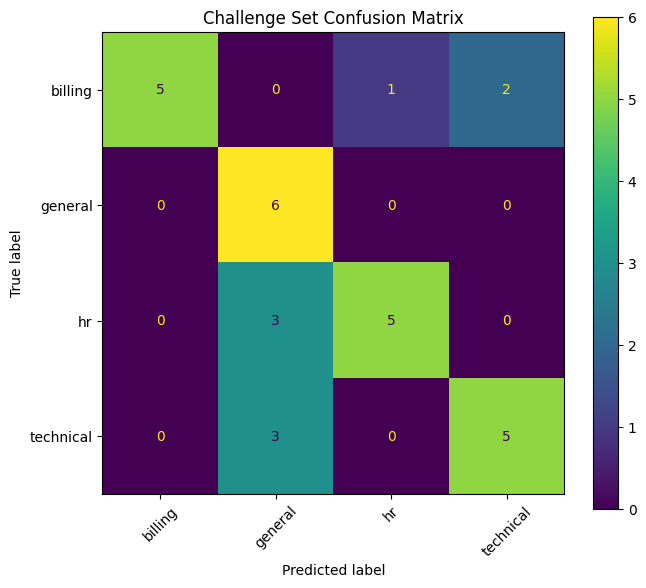

In [53]:
challenge_cm = confusion_matrix(
    challenge_df["actual_department"],
    challenge_df["predicted_department"],
    labels=le.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=challenge_cm,
    display_labels=le.classes_
).plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Challenge Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [54]:
print(
    f"Best 5-Fold CV Macro F1: "
    f"{grid_search.best_score_:.4f}"
)

Best 5-Fold CV Macro F1: 0.9975


In [57]:
summary = pd.DataFrame({
    "Evaluation": [
        "5-Fold Cross Validation",
        "Hold-out Test",
        "Challenge / Unseen Set"
    ],

    "Metric": [
        "Macro F1",
        "Macro F1",
        "Accuracy"
    ],

    "Score": [
        grid_search.best_score_,
        macro_f1,
        challenge_accuracy
    ]
})

summary

,Evaluation,Metric,Score
0,5-Fold Cross Validation,Macro F1,0.997483
1,Hold-out Test,Macro F1,1.000000
2,Challenge / Unseen Set,Accuracy,0.700000


In [56]:
macro_f1 = f1_score(y_test, y_pred, average='macro')